In [1]:
from dataclasses import asdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
clustering_run = ds.pipeline.open(label="docs_default")
graph = clustering_run["connectivity_map"]
umap = clustering_run["umap"]
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])

Downloading bucket files: 56073178 / 56073178 complete

Downloading bytes: 56073178 / 56073178 complete

In [2]:
leiden_refs = {
    0.3: ds.run_leiden_clustering(graph, resolution=0.3),
    0.5: clustering_run["leiden_0.5"],
    0.8: ds.run_leiden_clustering(graph, resolution=0.8),
}
leiden_values = {
    resolution: np.asarray(ds.load_artifact(ref)["values"][:])
    for resolution, ref in leiden_refs.items()
}

pd.DataFrame(
    {
        resolution: pd.Series(values).value_counts()
        for resolution, values in leiden_values.items()
    }
).fillna(0).astype(int)

,0.3,0.5,0.8
1,699,699,288
2,239,25,408
3,1289,242,28
4,317,1239,242
5,372,317,529
6,142,522,288
7,259,142,279
8,583,256,431
9,25,483,253
10,15,15,143


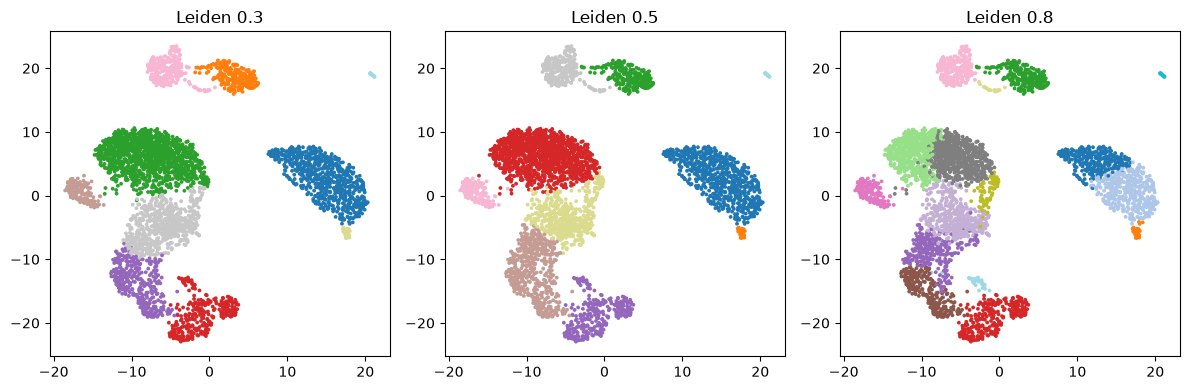

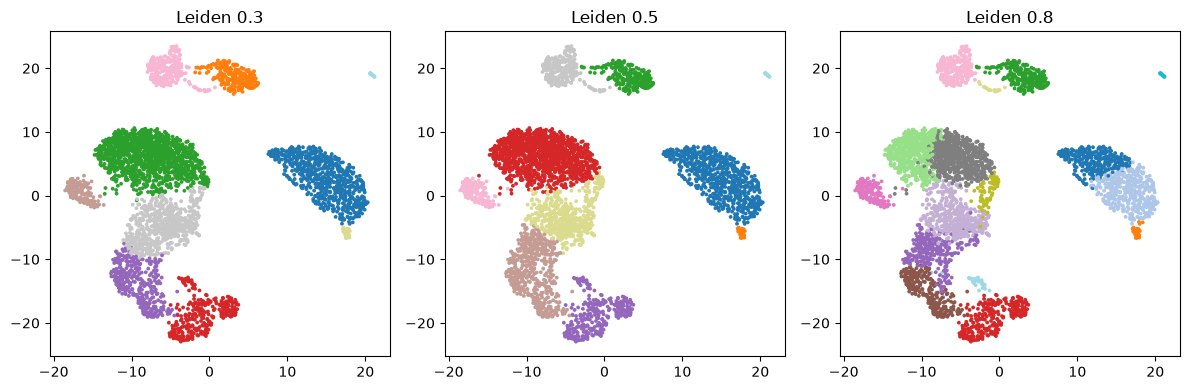

In [3]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, resolution in zip(axes, leiden_values, strict=True):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=leiden_values[resolution],
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"Leiden {resolution}")
figure.tight_layout()
figure

In [4]:
agreement = []
for first, second in combinations(leiden_values, 2):
    agreement.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": adjusted_rand_score(
                leiden_values[first],
                leiden_values[second],
            ),
            "NMI": normalized_mutual_info_score(
                leiden_values[first],
                leiden_values[second],
            ),
        }
    )
pd.DataFrame(agreement)

,comparison,ARI,NMI
0,0.3 vs 0.5,0.909628,0.928410
1,0.3 vs 0.8,0.611812,0.824495
2,0.5 vs 0.8,0.644235,0.844158


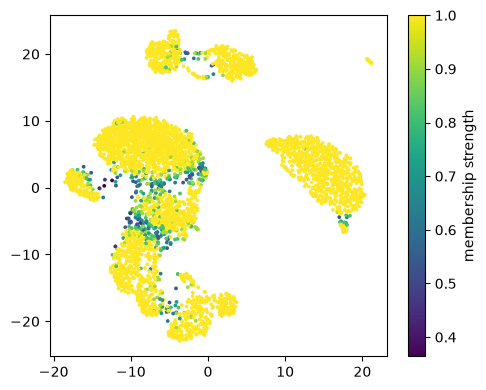

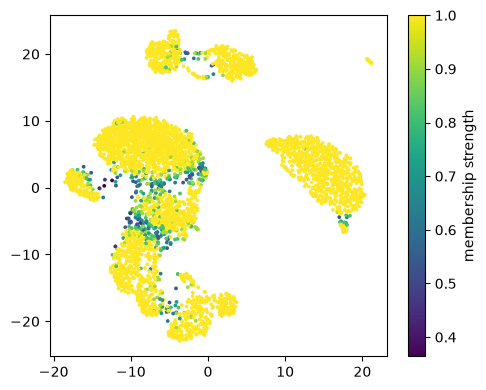

In [5]:
chosen = leiden_refs[0.5]
chosen_values = leiden_values[0.5]
membership = ds.calc_membership_strength(chosen, graph)
membership_values = np.asarray(ds.load_artifact(membership)["values"][:])

figure, axis = plt.subplots(figsize=(5, 4))
points = axis.scatter(
    umap_values[:, 0],
    umap_values[:, 1],
    c=membership_values,
    s=3,
)
figure.colorbar(points, ax=axis, label="membership strength")
figure.tight_layout()
figure

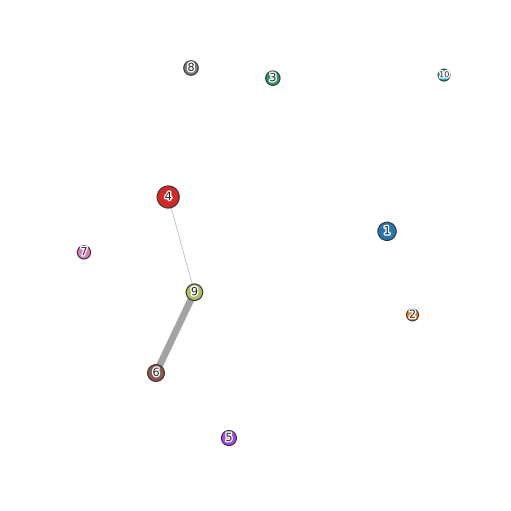

In [6]:
ds.plots.cluster_connectivity(
    graph=graph,
    groups=chosen,
    layout=umap,
)

In [7]:
paris_auto = ds.run_paris_clustering(graph)
paris_result = ds.load_paris_clustering(paris_auto)
pd.DataFrame([asdict(item) for item in paris_result.diagnostics])[
    ["label", "size", "persistence", "decision_margin", "forced"]
]

,label,size,persistence,decision_margin,forced
0,1,695,150.888618,NaN,False
1,2,228,140.489781,0.535172,False
2,3,1300,396.020421,0.147407,False
3,4,321,147.088507,0.245791,False
4,5,377,135.633677,0.148221,False
5,6,146,107.198268,0.640390,False
6,7,271,56.287076,NaN,False
7,8,559,154.446228,0.062985,False
8,9,28,21.347653,NaN,False
9,10,15,NaN,NaN,True


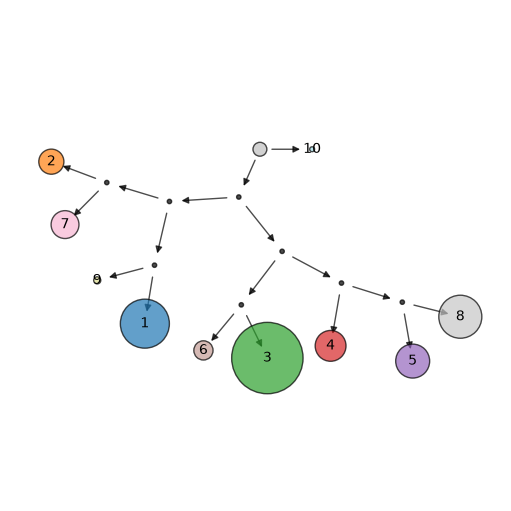

In [8]:
ds.plots.cluster_tree(graph=graph, clusters=paris_auto)

In [9]:
paris_fixed = ds.run_paris_clustering(
    graph,
    n_clusters=paris_result.n_clusters,
)
paris_auto_values = np.asarray(ds.load_artifact(paris_auto)["labels"][:])
paris_fixed_values = np.asarray(ds.load_artifact(paris_fixed)["labels"][:])
pd.Series(
    {
        "auto vs fixed ARI": adjusted_rand_score(
            paris_auto_values,
            paris_fixed_values,
        ),
        "Leiden vs Paris ARI": adjusted_rand_score(
            chosen_values,
            paris_auto_values,
        ),
    }
)

auto vs fixed ARI      1.00000
Leiden vs Paris ARI    0.88066
dtype: float64

In [10]:
markers = ds.run_marker_search(
    chosen,
    features=clustering_run["feature_universe"],
)
sizes = pd.Series(chosen_values).value_counts()
largest = sizes.index[0]
smallest = sizes.index[-1]

largest_markers = ds.get_markers(marker=markers, group_id=largest)
smallest_markers = ds.get_markers(marker=markers, group_id=smallest)

In [11]:
largest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.61010,0.60899,2.226800e-107,3.930654e-105
1,FHIT,0.52636,0.77753,3.175687e-287,3.803792e-284
2,TSHZ2,0.49994,0.63882,6.159739e-121,1.299279e-118
3,TCEA3,0.49036,0.59298,4.791068e-80,5.150091e-78
4,CHRM3-AS2,0.46122,0.66246,3.430929e-144,9.588876e-142
5,CMTM8,0.43404,0.61923,1.490711e-85,1.915535e-83
6,EPHX2,0.43301,0.66494,3.037417e-141,8.215234e-139
7,MAN1C1,0.40962,0.62229,1.715152e-84,2.146372e-82
8,LRRN3,0.39677,0.73626,7.581185e-246,6.053757e-243
9,MAL,0.38903,0.76996,8.139245e-237,5.686958e-234


In [12]:
smallest_markers[
    ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,TPM2,0.83577,0.96476,1.067142e-67,3.283469e-65
1,SERPINF1,0.83094,0.99686,1.588153e-124,8.877246e-122
2,LILRA4,0.81141,0.99976,6.433749e-215,6.165002e-212
3,MAP1A,0.81060,0.96034,3.856173e-109,1.771621e-106
4,IL3RA,0.80494,1.00000,2.059920e-169,1.570127e-166
5,SMPD3,0.79539,0.99774,7.555568e-210,7.038851e-207
6,DNASE1L3,0.79296,0.99868,1.610167e-192,1.421099e-189
7,GAS6,0.78591,0.99888,1.058090e-270,1.774312e-267
8,DERL3,0.77972,0.96439,2.449708e-130,1.467113e-127
9,FCER1A,0.76391,0.82660,4.347757e-62,1.257027e-59
